# 02 — Data Preprocessing — Axe 2 : Stroke Severity (Version 2 — Améliorée)

**Projet :** Stroke Prediction AI — IST Dataset  
**Notebook :** 02 — Preprocessing V2  
**Version :** V2 — Baseline stricte + corrections méthodologiques  
**Dataset :** `IST_corrected.csv` — 19 435 patients · 112 variables  
**Auteur :** ML_Project 2025-2026

---

## Objectif de ce notebook

Ce notebook est la version **améliorée** du preprocessing V1.  
Il corrige les 4 problèmes identifiés lors de la révision critique de la V1 :

| Problème V1 | Correction V2 |
|-------------|---------------|
| `RSBP = 0` traité comme donnée valide | Remplacé par NaN avant imputation |
| `C` dans RDEF → NaN naïf | Encodage `0.5` + indicateur `_uncertain` par colonne |
| Pas de `StandardScaler` | Ajouté dans le sous-pipeline numérique |
| Logique anti-leakage incorrecte (`AGE`, `RSBP` retirés à tort) | Correction : seuls `RCONSC` et `RDEF1..8` retirés |

## Pipeline de ce notebook

```
Dataset brut (19 435 patients)
    ↓ build_severity_target()
severity_class construite (19 418 patients avec cible)
    ↓ Corrections V2 (RSBP=0→NaN, C→0.5+indicateur)
    ↓ Features V2 strictes (sans RCONSC ni RDEF — leakage retiré)
    ↓ Feature Engineering V2 (score composites)
    ↓ Split stratifié 80/20
    ↓ ColumnTransformer V2 (imputation + StandardScaler + OneHot)
    ↓ SMOTE sur X_train uniquement
X_train_smote / X_test / y_train_smote / y_test
    ↓ Sauvegarde artefacts → artifacts/axe2/v2/
```

---


---
## Section 1 — Configuration et imports

### 1.1 Nouveautés V2 dans les imports

Par rapport à la V1, on ajoute :
- `StandardScaler` : obligatoire pour la Régression Logistique (sensible aux échelles)
- `SMOTE` (imbalanced-learn) : traitement actif du déséquilibre `sévère = 8%`
- `matplotlib` + `seaborn` : visualisations du preprocessing (distributions avant/après)


In [1]:
# ============================================================
# 1.1 — Imports V2 (avec SMOTE et StandardScaler)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os, sys, json, joblib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# SMOTE — oversampling de la classe minoritaire
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print(" imbalanced-learn disponible → SMOTE activé")
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn non disponible → installer : pip install imbalanced-learn")

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

print("Tous les imports chargés")


 imbalanced-learn disponible → SMOTE activé
Tous les imports chargés


In [2]:
# ============================================================
# 1.2 — Montage Drive + configuration centralisée
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/ML_Project")
SRC_PATH     = PROJECT_ROOT / "src"
ARTIFACTS_V2 = PROJECT_ROOT / "artifacts" / "axe2" / "v2"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import importlib, config
importlib.reload(config)

from config import (
    DATA_PATH, RANDOM_STATE,
    load_features, check_data_quality, ensure_directories,
)
from axe2_utils import (
    build_severity_target,
    get_feature_versions,
    encode_rconsc_if_present,
)

ensure_directories()
ARTIFACTS_V2.mkdir(parents=True, exist_ok=True)
TARGET = "severity_class"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"ARTIFACTS_V2  : {ARTIFACTS_V2}")
print(f"RANDOM_STATE  : {RANDOM_STATE}")
print("Configuration V2 chargée")


Mounted at /content/drive
PROJECT_ROOT  : /content/drive/MyDrive/ML_Project
ARTIFACTS_V2  : /content/drive/MyDrive/ML_Project/artifacts/axe2/v2
RANDOM_STATE  : 42
Configuration V2 chargée


---
## Section 2 — Chargement du dataset et des variables EDA


In [3]:
# ============================================================
# 2.1 — Chargement dataset brut + features EDA
# ============================================================

df = pd.read_csv(DATA_PATH, encoding="latin1", low_memory=False)
print(f"Shape dataset brut : {df.shape[0]:,} patients · {df.shape[1]} variables")

EDA_TARGET, EDA_CATEGORICAL_VARS, EDA_NUMERICAL_VARS, EDA_ALL_FEATURES = load_features()
print(f"Features EDA rechargées : {len(EDA_ALL_FEATURES)} variables baseline")

check_data_quality(df)


Shape dataset brut : 19,435 patients · 112 variables

📦 features.json chargé
🔹 target      : stroke
🔹 categorical : 17
🔹 numerical   : 3
Features EDA rechargées : 20 variables baseline
📊 DATA QUALITY REPORT

🔎 Valeurs manquantes totales : 379257

Colonnes avec valeurs manquantes :
FLASTD      19377
DRSHD       19338
DPED        19310
DMAJNCHX    19290
DMAJNCHD    19286
            ...  
FU1_RECD       13
CMPLHEP        13
CMPLASP        13
TD              2
ONDRUG          1
Length: 62, dtype: int64

🔁 Doublons : 0
✅ Aucun doublon

📐 Shape : 19435 lignes x 112 colonnes


np.False_

---
## Section 3 — Construction de la cible `severity_class`


In [4]:
# ============================================================
# 3.1 — Construction de severity_class
# ============================================================

df = build_severity_target(df)

n_before = len(df)
df_model = df.dropna(subset=[TARGET]).copy()
n_after  = len(df_model)

print(f"Patients avec cible calculable : {n_after:,} ({n_after/n_before*100:.1f}%)")
print(f"Patients retirés (NaN cible)   : {n_before-n_after}")

dist    = df_model[TARGET].value_counts()
dist_pct = df_model[TARGET].value_counts(normalize=True)*100
print()
print("Distribution de la cible :")
for cls in ["leger","modere","severe"]:
    print(f"  {cls:8s} : {dist[cls]:5d} ({dist_pct[cls]:.1f}%)")


Patients avec cible calculable : 19,418 (99.9%)
Patients retirés (NaN cible)   : 17

Distribution de la cible :
  leger    :  9692 (49.9%)
  modere   :  8096 (41.7%)
  severe   :  1630 (8.4%)


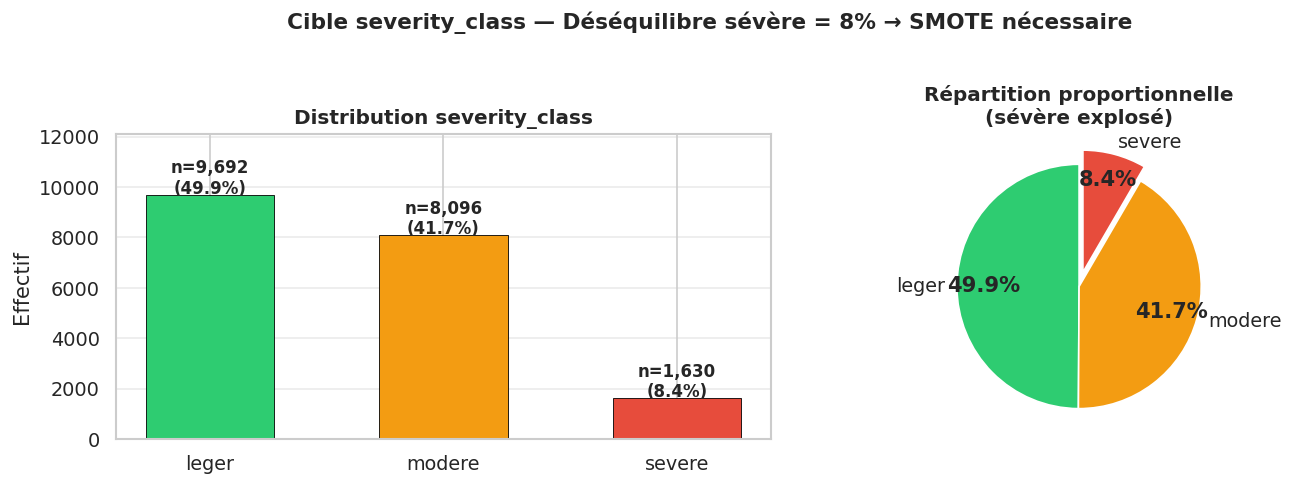

Graphique sauvegardé


In [5]:
# ============================================================
# 3.2 — Visualisation distribution de la cible
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order   = ["leger", "modere", "severe"]
colors  = {"leger":"#2ecc71", "modere":"#f39c12", "severe":"#e74c3c"}
dist_v  = df_model[TARGET].value_counts().reindex(order)
total   = dist_v.sum()

# Barplot
bars = axes[0].bar(order, [dist_v[c] for c in order],
                   color=[colors[c] for c in order], edgecolor="black", lw=0.5, width=0.55)
for bar, cls in zip(bars, order):
    pct = dist_v[cls]/total*100
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"n={dist_v[cls]:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Distribution severity_class", fontweight="bold")
axes[0].set_ylabel("Effectif")
axes[0].set_ylim(0, dist_v.max()*1.25)
axes[0].grid(axis="y", alpha=0.4)

# Pie
wedges, texts, autotexts = axes[1].pie(
    [dist_v[c] for c in order],
    labels=order,
    colors=[colors[c] for c in order],
    autopct="%1.1f%%", startangle=90, explode=(0,0,0.12),
    pctdistance=0.78
)
for at in autotexts: at.set_fontweight("bold")
axes[1].set_title("Répartition proportionnelle\n(sévère explosé)", fontweight="bold")

plt.suptitle("Cible severity_class — Déséquilibre sévère = 8% → SMOTE nécessaire",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé")


---
## Section 4 — Corrections V2 : RSBP=0 et traitement des "C" dans RDEF

### 4.1 Correction RSBP = 0

`RSBP` représente la pression artérielle systolique. Une valeur de `0 mmHg` est  
physiologiquement impossible — c'est une **erreur de saisie** masquée en 0.  
En V1, ces valeurs étaient imputable comme des données valides.  
En V2, on les convertit en `NaN` avant l'imputation, afin qu'elles soient  
correctement traitées par la médiane du train set.

### 4.2 Correction traitement des "C" dans RDEF

`C = "can't assess"` signifie que l'évaluateur ne pouvait pas tester ce déficit  
(patient inconscient, non-coopératif). C'est de l'**information clinique**, pas un NaN.

| Encodage | V1 (naïf) | V2 (correct) |
|----------|-----------|--------------|
| `Y` | 1 | 1 |
| `N` | 0 | 0 |
| `C` | NaN → imputation médiane ≈ 0 | **0.5** (entre absent et présent) + indicateur binaire `RDEF_i_uncertain` |

L'indicateur `_uncertain = 1` permet au modèle d'apprendre que  
"non évaluable" est une information distincte de "absent".


In [6]:
# ============================================================
# 4.1 — Correction RSBP = 0 → NaN
# ============================================================

n_rsbp_zero = (df_model["RSBP"] == 0).sum()
print(f"RSBP = 0 avant correction : {n_rsbp_zero} patients")

df_model["RSBP"] = df_model["RSBP"].replace(0, np.nan)

n_rsbp_nan = df_model["RSBP"].isna().sum()
print(f"RSBP NaN après correction  : {n_rsbp_nan} patients (seront imputés par médiane train)")
print()
print(f"  Médiane RSBP (hors NaN)  : {df_model['RSBP'].median():.0f} mmHg")
print(f"  Min RSBP (hors NaN)      : {df_model['RSBP'].min():.0f} mmHg")
print(f"  Max RSBP                 : {df_model['RSBP'].max():.0f} mmHg")
print()
print("RSBP=0 remplacé par NaN — sera imputable par médiane du train set")


RSBP = 0 avant correction : 0 patients
RSBP NaN après correction  : 0 patients (seront imputés par médiane train)

  Médiane RSBP (hors NaN)  : 160 mmHg
  Min RSBP (hors NaN)      : 70 mmHg
  Max RSBP                 : 295 mmHg

RSBP=0 remplacé par NaN — sera imputable par médiane du train set


In [7]:
# ============================================================
# 4.2 — Correction traitement des "C" dans RDEF (V2)
# ============================================================

rdef_cols = [f"RDEF{i}" for i in range(1, 9)]

# Statistiques AVANT correction
print("Taux de 'C' dans RDEF (AVANT correction V2) :")
for col in rdef_cols:
    pct_c = (df_model[col] == "C").mean() * 100
    print(f"  {col} : {pct_c:.2f}% de 'C'")

print()

# Encodage V2 : Y→1, N→0, C→0.5 + indicateur
for col in rdef_cols:
    # Valeur 0.5 pour C (entre absent=0 et présent=1)
    df_model[col + "_v2"] = df_model[col].map({"Y": 1.0, "N": 0.0, "C": 0.5})

    # Indicateur binaire : 1 si C (non évaluable), 0 sinon
    df_model[col + "_uncertain"] = (df_model[col] == "C").astype(int)

print("Création des features RDEF V2 :")
print("  → RDEF_i_v2        : Y=1, N=0, C=0.5 (valeur intermédiaire)")
print("  → RDEF_i_uncertain : 1 si C, 0 sinon (signal 'non évaluable')")

# Vérification
sample_cols = ["RDEF1", "RDEF1_v2", "RDEF1_uncertain"]
display(df_model[sample_cols].head(10))


Taux de 'C' dans RDEF (AVANT correction V2) :
  RDEF1 : 1.18% de 'C'
  RDEF2 : 0.55% de 'C'
  RDEF3 : 1.23% de 'C'
  RDEF4 : 2.92% de 'C'
  RDEF5 : 20.23% de 'C'
  RDEF6 : 17.67% de 'C'
  RDEF7 : 8.11% de 'C'
  RDEF8 : 6.34% de 'C'

Création des features RDEF V2 :
  → RDEF_i_v2        : Y=1, N=0, C=0.5 (valeur intermédiaire)
  → RDEF_i_uncertain : 1 si C, 0 sinon (signal 'non évaluable')


,RDEF1,RDEF1_v2,RDEF1_uncertain
0,N,0.0000,0
1,Y,1.0000,0
2,Y,1.0000,0
3,N,0.0000,0
4,Y,1.0000,0
5,Y,1.0000,0
6,Y,1.0000,0
7,N,0.0000,0
8,N,0.0000,0
9,N,0.0000,0


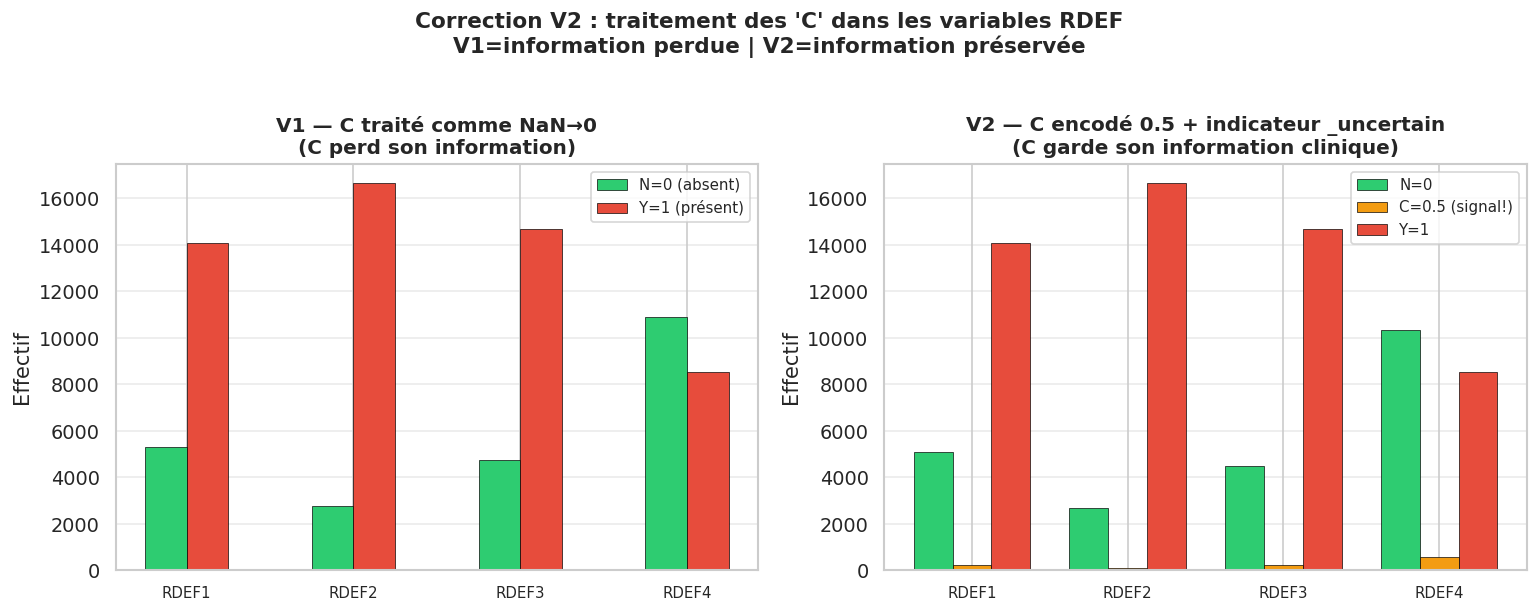

Graphique correction RDEF sauvegardé


In [8]:
# ============================================================
# 4.3 — Visualisation : impact de la correction C → 0.5
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rdef_plot = rdef_cols[:4]  # 4 premiers RDEF pour lisibilité

# V1 : distribution après encodage naïf (C→NaN→médiane≈0)
rdef_v1_data = {}
for col in rdef_plot:
    v1_enc = df_model[col].map({"Y": 1, "N": 0, "C": np.nan}).fillna(0)
    rdef_v1_data[col] = v1_enc.value_counts().to_dict()

# V2 : distribution après encodage correct
rdef_v2_data = {}
for col in rdef_plot:
    v2_enc = df_model[col + "_v2"]
    rdef_v2_data[col] = v2_enc.value_counts().to_dict()

x      = np.arange(len(rdef_plot))
w      = 0.25
labels = ["N=0", "C→0", "Y=1"] # V1 (C imputable à 0)
labels2= ["N=0", "C=0.5", "Y=1"] # V2

vals_v1_0 = [rdef_v1_data[c].get(0, 0) for c in rdef_plot]
vals_v1_1 = [rdef_v1_data[c].get(1, 0) for c in rdef_plot]
vals_v2_0   = [rdef_v2_data[c].get(0.0, 0) for c in rdef_plot]
vals_v2_05  = [rdef_v2_data[c].get(0.5, 0) for c in rdef_plot]
vals_v2_1   = [rdef_v2_data[c].get(1.0, 0) for c in rdef_plot]

axes[0].bar(x - w/2, vals_v1_0, w, label="N=0 (absent)",    color="#2ecc71", edgecolor="black", lw=0.4)
axes[0].bar(x + w/2, vals_v1_1, w, label="Y=1 (présent)",   color="#e74c3c", edgecolor="black", lw=0.4)
axes[0].set_xticks(x); axes[0].set_xticklabels(rdef_plot, fontsize=9)
axes[0].set_title("V1 — C traité comme NaN→0\n(C perd son information)", fontweight="bold")
axes[0].set_ylabel("Effectif"); axes[0].legend(fontsize=9); axes[0].grid(axis="y", alpha=0.4)

axes[1].bar(x - w,   vals_v2_0,  w, label="N=0",            color="#2ecc71", edgecolor="black", lw=0.4)
axes[1].bar(x,       vals_v2_05, w, label="C=0.5 (signal!)", color="#f39c12", edgecolor="black", lw=0.4)
axes[1].bar(x + w,   vals_v2_1,  w, label="Y=1",             color="#e74c3c", edgecolor="black", lw=0.4)
axes[1].set_xticks(x); axes[1].set_xticklabels(rdef_plot, fontsize=9)
axes[1].set_title("V2 — C encodé 0.5 + indicateur _uncertain\n(C garde son information clinique)", fontweight="bold")
axes[1].set_ylabel("Effectif"); axes[1].legend(fontsize=9); axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Correction V2 : traitement des 'C' dans les variables RDEF\nV1=information perdue | V2=information préservée",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_rdef_correction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique correction RDEF sauvegardé")


---
## Section 5 — Feature Engineering V2

### 5.1 Pourquoi créer des variables composites ?

Le Feature Engineering permet de créer de nouvelles variables plus informatives  
à partir des variables brutes. En V2, on crée 3 scores composites cliniquement justifiés :

| Feature créée | Construction | Justification clinique |
|--------------|-------------|------------------------|
| `n_deficits_confirmed` | Σ RDEF_i_v2 où Y=1 | Nombre de déficits confirmés |
| `n_deficits_uncertain` | Σ RDEF_i_uncertain | Nombre de C = patients non évaluables |
| `deficit_ratio` | confirmed / (confirmed + certain) | Proportion de déficits sur évaluables |


In [9]:
# ============================================================
# 5.1 — Feature Engineering V2 : scores composites RDEF
# ============================================================

rdef_v2_cols       = [col + "_v2" for col in rdef_cols]
rdef_uncert_cols   = [col + "_uncertain" for col in rdef_cols]

# Nombre de déficits confirmés (Y uniquement)
df_model["n_deficits_confirmed"] = (
    df_model[[f"RDEF{i}_v2" for i in range(1,9)]] == 1.0
).sum(axis=1)

# Nombre de déficits non évaluables (C uniquement)
df_model["n_deficits_uncertain"] = df_model[rdef_uncert_cols].sum(axis=1)

# Ratio : déficits confirmés / total évaluable (evite division par 0)
total_evaluated = (df_model[[f"RDEF{i}_v2" for i in range(1,9)]] != 0.5).sum(axis=1)
df_model["deficit_ratio"] = np.where(
    total_evaluated > 0,
    df_model["n_deficits_confirmed"] / total_evaluated,
    0
)

# Vérification
print("Features composites créées :")
print(df_model[["n_deficits_confirmed","n_deficits_uncertain","deficit_ratio"]].describe().round(3))

print()
print("Corrélation avec la cible (severité) :")
target_num = df_model[TARGET].map({"leger":0,"modere":1,"severe":2})
for feat in ["n_deficits_confirmed","n_deficits_uncertain","deficit_ratio"]:
    corr = df_model[feat].corr(target_num)
    print(f"  {feat:30s} : r = {corr:.3f}")


Features composites créées :
       n_deficits_confirmed  n_deficits_uncertain  deficit_ratio
count            19418.0000            19418.0000     19418.0000
mean                 3.2730                0.5820         0.4590
std                  1.2740                1.1100         0.2080
min                  0.0000                0.0000         0.0000
25%                  2.0000                0.0000         0.3330
50%                  3.0000                0.0000         0.4290
75%                  4.0000                1.0000         0.6250
max                  8.0000                7.0000         1.0000

Corrélation avec la cible (severité) :
  n_deficits_confirmed           : r = 0.784
  n_deficits_uncertain           : r = 0.286
  deficit_ratio                  : r = 0.774


---
## Section 6 — Sélection des features V2 (anti-leakage correct)

### 6.1 Correction de la logique anti-leakage

En V2 configurée originale, un bug retirait `AGE` et `RSBP` à tort.  
Ces variables sont disponibles à l'admission et **n'entrent pas** dans la formule de sévérité.

**Variables à retirer en V2 (leakage structurel réel) :**
```
RCONSC, RDEF1, RDEF2, ..., RDEF8
→ ces variables entrent directement dans severity_score
```

**Variables à conserver (légitimes) :**
```
AGE, RSBP, RDELAY, STYPE, SEX, RATRIAL, RCT, RVISINF, RHEP24, RASP3, RSLEEP
```


In [10]:
# ============================================================
# 6.1 — Définition correcte des features V2
# ============================================================

# Features RDEF V2 (encodage corrigé) + incertitude
rdef_v2_feature_cols     = [f"RDEF{i}_v2"        for i in range(1, 9)]
rdef_uncertain_feat_cols = [f"RDEF{i}_uncertain"  for i in range(1, 9)]

# Features baseline V2 (sans RCONSC ni RDEF bruts — leakage structurel retiré)
# AGE et RSBP sont conservés (légitimes — ne participent pas au calcul de severity_score)
FEATURES_V2_CORRECT = [
    # Numériques
    "RDELAY", "AGE", "RSBP",
    # Catégorielles
    "SEX", "RSLEEP", "RATRIAL", "RCT", "RVISINF", "RHEP24", "RASP3", "STYPE",
    # RDEF encodés V2 (Y=1, N=0, C=0.5)
] + rdef_v2_feature_cols + rdef_uncertain_feat_cols + [
    # Features composites
    "n_deficits_confirmed", "n_deficits_uncertain", "deficit_ratio"
]

# Filtrer les colonnes présentes
FEATURES_V2_CORRECT = [c for c in FEATURES_V2_CORRECT if c in df_model.columns]

X = df_model[FEATURES_V2_CORRECT].copy()
y = df_model[TARGET].copy()

print(f"Features V2 sélectionnées : {len(FEATURES_V2_CORRECT)}")
print()
for f in FEATURES_V2_CORRECT:
    print(f"  - {f}")
print()
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")


Features V2 sélectionnées : 30

  - RDELAY
  - AGE
  - RSBP
  - SEX
  - RSLEEP
  - RATRIAL
  - RCT
  - RVISINF
  - RHEP24
  - RASP3
  - STYPE
  - RDEF1_v2
  - RDEF2_v2
  - RDEF3_v2
  - RDEF4_v2
  - RDEF5_v2
  - RDEF6_v2
  - RDEF7_v2
  - RDEF8_v2
  - RDEF1_uncertain
  - RDEF2_uncertain
  - RDEF3_uncertain
  - RDEF4_uncertain
  - RDEF5_uncertain
  - RDEF6_uncertain
  - RDEF7_uncertain
  - RDEF8_uncertain
  - n_deficits_confirmed
  - n_deficits_uncertain
  - deficit_ratio

Shape X : (19418, 30)
Shape y : (19418,)


---
## Section 7 — Identification des types de variables et valeurs manquantes


In [11]:
# ============================================================
# 7.1 — Séparation numériques / catégorielles
# ============================================================

numeric_features     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Variables NUMÉRIQUES ({len(numeric_features)}) :")
for c in numeric_features: print(f"  - {c}")
print()
print(f"Variables CATÉGORIELLES ({len(categorical_features)}) :")
for c in categorical_features: print(f"  - {c}")


Variables NUMÉRIQUES (22) :
  - RDELAY
  - AGE
  - RSBP
  - RDEF1_v2
  - RDEF2_v2
  - RDEF3_v2
  - RDEF4_v2
  - RDEF5_v2
  - RDEF6_v2
  - RDEF7_v2
  - RDEF8_v2
  - RDEF1_uncertain
  - RDEF2_uncertain
  - RDEF3_uncertain
  - RDEF4_uncertain
  - RDEF5_uncertain
  - RDEF6_uncertain
  - RDEF7_uncertain
  - RDEF8_uncertain
  - n_deficits_confirmed
  - n_deficits_uncertain
  - deficit_ratio

Variables CATÉGORIELLES (8) :
  - SEX
  - RSLEEP
  - RATRIAL
  - RCT
  - RVISINF
  - RHEP24
  - RASP3
  - STYPE


In [12]:
# ============================================================
# 7.2 — Valeurs manquantes dans X (post-corrections V2)
# ============================================================

missing_count = X.isna().sum()
missing_pct   = (X.isna().mean() * 100)
missing_sum   = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct (%)": missing_pct.round(2)
}).sort_values("missing_count", ascending=False)

avec_nan = missing_sum[missing_sum["missing_count"] > 0]
print(f"Variables avec NaN ({len(avec_nan)}) :")
display(avec_nan)
print()
print("Stratégie d'imputation V2 :")
print("  → Numériques  : médiane (robuste) — StandardScaler appliqué ensuite")
print("  → Catégorielles : mode (most_frequent) → OneHotEncoder")
print("  → RDEF_v2 (numériques)   : médiane (0 ou 0.5 ou 1)")
print("  → RDEF_uncertain (binaires): médiane = 0 (majorité non-C)")


Variables avec NaN (3) :


,missing_count,missing_pct (%)
RATRIAL,983,5.0600
RASP3,983,5.0600
RHEP24,343,1.7700



Stratégie d'imputation V2 :
  → Numériques  : médiane (robuste) — StandardScaler appliqué ensuite
  → Catégorielles : mode (most_frequent) → OneHotEncoder
  → RDEF_v2 (numériques)   : médiane (0 ou 0.5 ou 1)
  → RDEF_uncertain (binaires): médiane = 0 (majorité non-C)


---
## Section 8 — Split train / test stratifié

### 8.1 Règle fondamentale : split AVANT toute transformation

Le split doit précéder l'imputation, le scaling et SMOTE.  
Toute statistique apprise (médiane, StandardScaler, distributions SMOTE)  
doit venir **exclusivement du train set**.


In [13]:
# ============================================================
# 8.1 — Split stratifié 80/20
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y   # conserve les proportions sévère=8%
)

print("=" * 50)
print("RÉSULTAT DU SPLIT V2")
print("=" * 50)
print(f"  X_train : {X_train.shape}  |  X_test : {X_test.shape}")

print()
print("Distribution des classes — TRAIN :")
for cls in ["leger","modere","severe"]:
    n   = (y_train == cls).sum()
    pct = n / len(y_train) * 100
    print(f"  {cls:8s} : {n:5d} ({pct:.1f}%)")

print()
print("Distribution des classes — TEST :")
for cls in ["leger","modere","severe"]:
    n   = (y_test == cls).sum()
    pct = n / len(y_test) * 100
    print(f"  {cls:8s} : {n:5d} ({pct:.1f}%)")

print()
print(" Stratification correcte — proportions conservées train/test")


RÉSULTAT DU SPLIT V2
  X_train : (15534, 30)  |  X_test : (3884, 30)

Distribution des classes — TRAIN :
  leger    :  7753 (49.9%)
  modere   :  6477 (41.7%)
  severe   :  1304 (8.4%)

Distribution des classes — TEST :
  leger    :  1939 (49.9%)
  modere   :  1619 (41.7%)
  severe   :   326 (8.4%)

 Stratification correcte — proportions conservées train/test


---
## Section 9 — Pipeline de preprocessing V2 avec StandardScaler

### 9.1 Nouveauté V2 : StandardScaler dans le sous-pipeline numérique

En V1, le pipeline numérique ne comprenait que l'imputation.  
En V2, on ajoute `StandardScaler` qui centre et réduit les variables numériques.

**Pourquoi c'est indispensable pour la Régression Logistique :**  
Sans scaling, `AGE` (plage 16–99) et `RSBP` (plage 70–300) dominent les features  
binaires (0/1) → la LR converge mal et produit des coefficients biaisés.

**Pourquoi l'ordre imputation → scaling est important :**  
Le `StandardScaler` calcule moyenne et écart-type. Si des NaN subsistent,  
ces statistiques sont faussées. L'imputation doit être faite en premier.

```
Pipeline NUMÉRIQUE V2 :
SimpleImputer(médiane) → StandardScaler()

Pipeline CATÉGORIEL V2 :
SimpleImputer(mode) → OneHotEncoder(handle_unknown='ignore')
```


In [14]:
# ============================================================
# 9.1 — Construction du ColumnTransformer V2
# ============================================================

# Recalcul des listes APRÈS le split (sur X_train pour la détection de type)
numeric_features_train     = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_train = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Sous-pipeline NUMÉRIQUE V2 : imputation + scaling
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # médiane = robuste aux extrêmes
    ("scaler",  StandardScaler()),                   # centre + réduit (obligatoire LR)
])

# Sous-pipeline CATÉGORIEL V2 : imputation + OHE
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer V2 complet
preprocessor_v2 = ColumnTransformer(transformers=[
    ("num", numeric_pipeline,     numeric_features_train),
    ("cat", categorical_pipeline, categorical_features_train),
])

print("Pipeline V2 construit :")
print(preprocessor_v2)


Pipeline V2 construit :
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['RDELAY', 'AGE', 'RSBP', 'RDEF1_v2',
                                  'RDEF2_v2', 'RDEF3_v2', 'RDEF4_v2',
                                  'RDEF5_v2', 'RDEF6_v2', 'RDEF7_v2',
                                  'RDEF8_v2', 'RDEF1_uncertain',
                                  'RDEF2_uncertain', 'RDEF3_uncertain',
                                  'RDEF4_uncertain', 'RDEF5_uncertain',
                                  'RDEF6_uncertain', 'RDEF7_uncertain',
                                  'RDEF8_uncertain', 'n_deficits_confirmed',
                                  'n_deficits_uncertain', 'deficit_ratio']),
                                ('cat',
                       

In [15]:
# ============================================================
# 9.2 — Fit sur train uniquement, transform sur train et test
# ============================================================

# FIT uniquement sur train — les statistiques du test ne polluent pas le pipeline
X_train_processed = preprocessor_v2.fit_transform(X_train)
X_test_processed  = preprocessor_v2.transform(X_test)

feature_names_out = preprocessor_v2.get_feature_names_out()

print(f"X_train_processed : {X_train_processed.shape}")
print(f"X_test_processed  : {X_test_processed.shape}")
print(f"Nb features après preprocessing : {len(feature_names_out)}")

# Conversion en DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_out, index=X_train.index)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names_out, index=X_test.index)

# Vérification : 0 NaN
print()
print(f"NaN dans X_train_df : {X_train_df.isna().sum().sum()}")
print(f"NaN dans X_test_df  : {X_test_df.isna().sum().sum()}")
print("0 NaN — preprocessing complet")


X_train_processed : (15534, 41)
X_test_processed  : (3884, 41)
Nb features après preprocessing : 41

NaN dans X_train_df : 0
NaN dans X_test_df  : 0
0 NaN — preprocessing complet


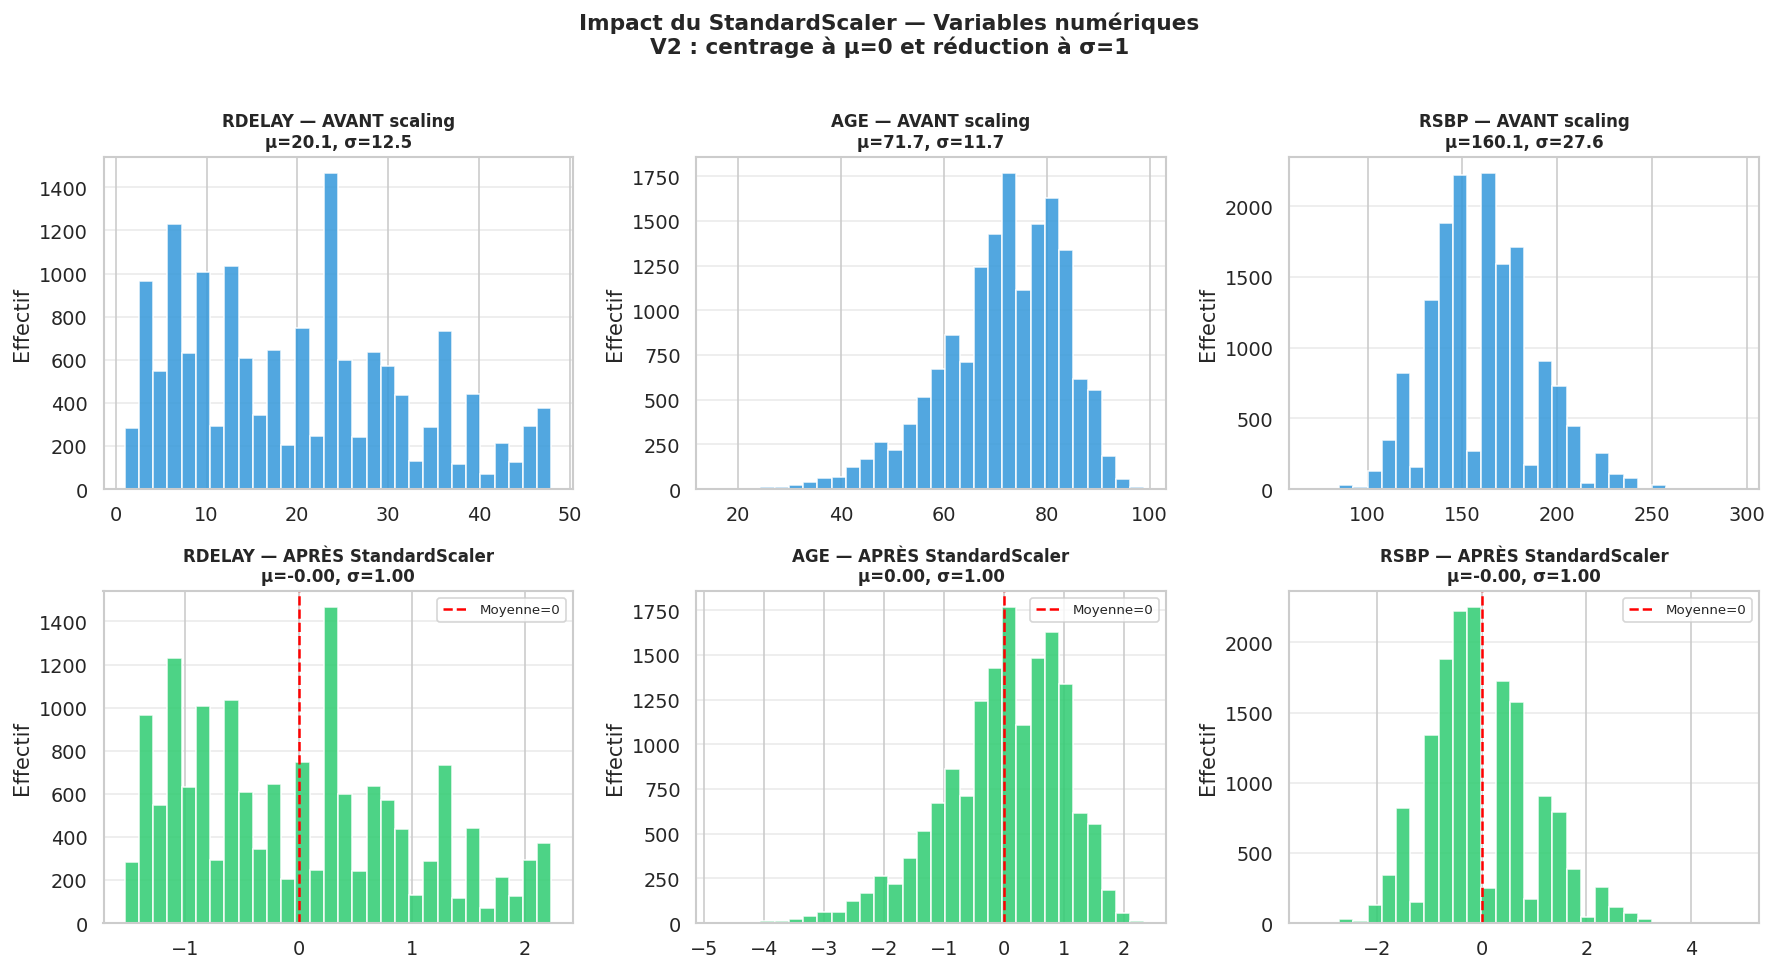

Graphique StandardScaler sauvegardé


In [16]:
# ============================================================
# 9.3 — Visualisation : impact du StandardScaler sur les variables numériques
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

clin_num         = ["RDELAY", "AGE", "RSBP"]
clin_num_present = [c for c in clin_num if c in X_train.columns]

for col, ax_before, ax_after in zip(
    clin_num_present,
    [axes[0, 0], axes[0, 1], axes[0, 2]],
    [axes[1, 0], axes[1, 1], axes[1, 2]]
):
    # ── Avant scaling ──────────────────────────────────────
    data_before = X_train[col].dropna()
    ax_before.hist(data_before, bins=30, color="#3498db",
                   edgecolor="white", lw=0.3, alpha=0.85)
    ax_before.set_title(
        f"{col} — AVANT scaling\nμ={data_before.mean():.1f}, σ={data_before.std():.1f}",
        fontsize=10, fontweight="bold"
    )
    ax_before.set_ylabel("Effectif")
    ax_before.grid(axis="y", alpha=0.4)

    # ── Après scaling ──────────────────────────────────────
    scaled_col = f"num__{col}"
    if scaled_col in X_train_df.columns:
        data_after = X_train_df[scaled_col]
        ax_after.hist(data_after, bins=30, color="#2ecc71",
                      edgecolor="white", lw=0.3, alpha=0.85)
        ax_after.axvline(0, color="red", lw=1.5, linestyle="--", label="Moyenne=0")
        ax_after.set_title(
            f"{col} — APRÈS StandardScaler\nμ={data_after.mean():.2f}, σ={data_after.std():.2f}",
            fontsize=10, fontweight="bold"
        )
        ax_after.set_ylabel("Effectif")
        ax_after.legend(fontsize=8)
        ax_after.grid(axis="y", alpha=0.4)

# ── CORRECTION : suptitle sur une seule ligne avec \n explicite ──
plt.suptitle(
    "Impact du StandardScaler — Variables numériques\nV2 : centrage à μ=0 et réduction à σ=1",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2 / "v2_standard_scaler_effect.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique StandardScaler sauvegardé")

---
## Section 10 — SMOTE : traitement actif du déséquilibre de classes

### 10.1 Pourquoi SMOTE et pas seulement class_weight ?

`class_weight='balanced'` pénalise plus les erreurs sur la classe minoritaire  
mais ne modifie pas la distribution des données.

SMOTE (Synthetic Minority Over-sampling Technique) crée de **nouveaux exemples synthétiques**  
de la classe `sévère` en interpolant dans l'espace des features entre exemples existants.

**Avantage :** le modèle voit plus d'exemples sévères → meilleur recall sur cette classe.  
**Règle absolue :** SMOTE uniquement sur `X_train` — jamais sur `X_test`.  
Appliquer SMOTE sur le test biaise l'évaluation (leakage de distribution).

### 10.2 Paramètres SMOTE

- `sampling_strategy='minority'` : sur-échantillonne uniquement la classe minoritaire (`sévère`)  
- `k_neighbors=5` : nombre de voisins pour l'interpolation (défaut sklearn)  
- `random_state=RANDOM_STATE` : reproductibilité


In [17]:
# ============================================================
# 10.1 — Application de SMOTE sur X_train uniquement
# ============================================================

TARGET_MAP = {"leger": 0, "modere": 1, "severe": 2}
y_train_enc = y_train.map(TARGET_MAP)
y_test_enc  = y_test.map(TARGET_MAP)

print("Distribution AVANT SMOTE (X_train) :")
for cls, label in [(0,"léger"), (1,"modéré"), (2,"sévère")]:
    n = (y_train_enc == cls).sum()
    print(f"  {label:8s} : {n:5d} ({n/len(y_train_enc)*100:.1f}%)")

if SMOTE_AVAILABLE:
    smote = SMOTE(
        sampling_strategy="minority",  # sur-échantillonne uniquement sévère
        k_neighbors=5,
        random_state=RANDOM_STATE
    )

    # SMOTE sur les données preprocessées (numpy array)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train_enc)

    print()
    print("Distribution APRÈS SMOTE (X_train_smote) :")
    counter = Counter(y_train_smote)
    total_smote = len(y_train_smote)
    for cls, label in [(0,"léger"), (1,"modéré"), (2,"sévère")]:
        n = counter[cls]
        print(f"  {label:8s} : {n:5d} ({n/total_smote*100:.1f}%)")
    print()
    print(f"  Taille avant SMOTE : {len(y_train_enc):,}")
    print(f"  Taille après SMOTE : {total_smote:,}")
    print(f"  Exemples synthétiques créés : {total_smote - len(y_train_enc):,}")
else:
    # Fallback sans SMOTE
    X_train_smote = X_train_processed
    y_train_smote = y_train_enc
    print(" SMOTE non disponible — utilisation de X_train sans oversampling")
    print("   → installer : pip install imbalanced-learn")


Distribution AVANT SMOTE (X_train) :
  léger    :  7753 (49.9%)
  modéré   :  6477 (41.7%)
  sévère   :  1304 (8.4%)

Distribution APRÈS SMOTE (X_train_smote) :
  léger    :  7753 (35.3%)
  modéré   :  6477 (29.5%)
  sévère   :  7753 (35.3%)

  Taille avant SMOTE : 15,534
  Taille après SMOTE : 21,983
  Exemples synthétiques créés : 6,449


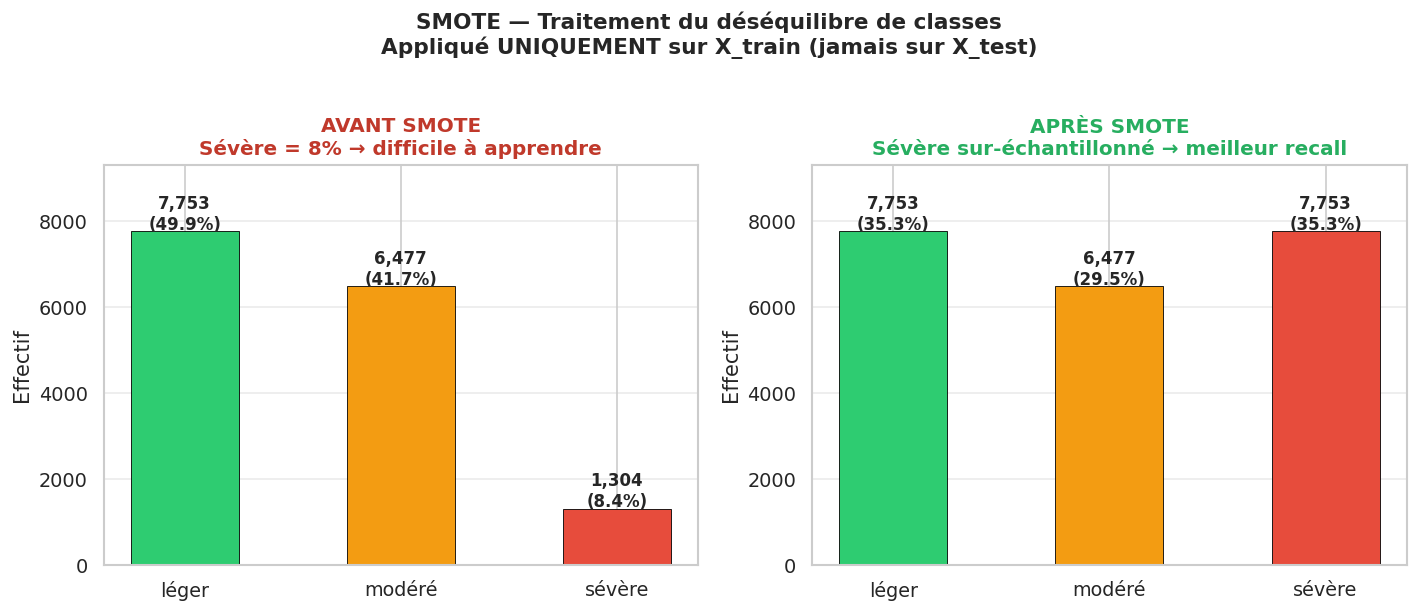

Graphique SMOTE sauvegardé


In [18]:
# ============================================================
# 10.2 — Visualisation : avant vs après SMOTE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
label_map = {0: "léger", 1: "modéré", 2: "sévère"}
colors    = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}

# AVANT SMOTE
counter_before = Counter(y_train_enc)
axes[0].bar(
    [label_map[k] for k in sorted(counter_before)],
    [counter_before[k] for k in sorted(counter_before)],
    color=[colors[k] for k in sorted(counter_before)],
    edgecolor="black", lw=0.5, width=0.5
)
for k in sorted(counter_before):
    n = counter_before[k]
    pct = n / len(y_train_enc) * 100
    axes[0].text(list(sorted(counter_before)).index(k), n+50,
                 f"{n:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("AVANT SMOTE\nSévère = 8% → difficile à apprendre",
                   fontweight="bold", color="#c0392b")
axes[0].set_ylabel("Effectif"); axes[0].grid(axis="y", alpha=0.4)
axes[0].set_ylim(0, max(counter_before.values()) * 1.2)

# APRÈS SMOTE
counter_after = Counter(y_train_smote)
axes[1].bar(
    [label_map[k] for k in sorted(counter_after)],
    [counter_after[k] for k in sorted(counter_after)],
    color=[colors[k] for k in sorted(counter_after)],
    edgecolor="black", lw=0.5, width=0.5
)
for k in sorted(counter_after):
    n = counter_after[k]
    pct = n / len(y_train_smote) * 100
    axes[1].text(list(sorted(counter_after)).index(k), n+50,
                 f"{n:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("APRÈS SMOTE\nSévère sur-échantillonné → meilleur recall",
                   fontweight="bold", color="#27ae60")
axes[1].set_ylabel("Effectif"); axes[1].grid(axis="y", alpha=0.4)
axes[1].set_ylim(0, max(counter_after.values()) * 1.2)

plt.suptitle("SMOTE — Traitement du déséquilibre de classes\nAppliqué UNIQUEMENT sur X_train (jamais sur X_test)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_smote_effect.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique SMOTE sauvegardé")


---
## Section 11 — Sauvegarde des artefacts V2


In [19]:
# ============================================================
# 11.1 — Sauvegarde de tous les artefacts V2
# ============================================================

print("Sauvegarde dans :", ARTIFACTS_V2)
print()

# X_train après SMOTE (numpy → DataFrame)
X_train_smote_df = pd.DataFrame(X_train_smote, columns=feature_names_out)
X_test_df_save   = pd.DataFrame(X_test_processed, columns=feature_names_out)

X_train_smote_df.to_csv(ARTIFACTS_V2/"X_train_smote.csv", index=False)
X_test_df_save.to_csv(ARTIFACTS_V2/"X_test_preprocessed.csv", index=False)
print(" X_train_smote.csv")
print("X_test_preprocessed.csv")

# Labels
pd.Series(y_train_smote, name="severity_class").to_csv(ARTIFACTS_V2/"y_train_smote.csv", index=False)
y_test_enc.to_csv(ARTIFACTS_V2/"y_test.csv", index=True)
print("y_train_smote.csv")
print("y_test.csv")

# Dataset nettoyé
df_model.to_csv(ARTIFACTS_V2/"df_axe2_clean_v2.csv", index=False)
print(" df_axe2_clean_v2.csv")

# Preprocesseur sérialisé
joblib.dump(preprocessor_v2, ARTIFACTS_V2/"preprocessor_v2.pkl")
print("preprocessor_v2.pkl")

# Métadonnées
metadata_v2 = {
    "version"               : "V2",
    "description"           : "Baseline stricte corrigée — RSBP=0→NaN, C→0.5+uncertain, StandardScaler, SMOTE",
    "n_patients_model"      : int(len(df_model)),
    "n_train_before_smote"  : int(len(y_train_enc)),
    "n_train_after_smote"   : int(len(y_train_smote)),
    "n_test"                : int(len(y_test_enc)),
    "n_features_before_prep": int(X.shape[1]),
    "n_features_after_prep" : int(X_train_smote_df.shape[1]),
    "selected_features"     : FEATURES_V2_CORRECT,
    "target_map"            : TARGET_MAP,
    "random_state"          : RANDOM_STATE,
    "smote_applied"         : SMOTE_AVAILABLE,
    "corrections_v2"        : [
        "RSBP=0 remplacé par NaN avant imputation",
        "C dans RDEF → 0.5 + indicateur _uncertain",
        "StandardScaler ajouté dans pipeline numérique",
        "AGE et RSBP conservés (retrait V1 était incorrect)",
        "SMOTE appliqué uniquement sur X_train"
    ]
}

with open(ARTIFACTS_V2/"preprocessing_metadata_v2.json", "w") as f:
    json.dump(metadata_v2, f, indent=2, default=str)
print("preprocessing_metadata_v2.json")
print()
print("=== Récapitulatif artefacts ===")
for f in sorted(ARTIFACTS_V2.glob("*")):
    if f.is_file():
        print(f"  {f.name:50s} {f.stat().st_size/1024:8.1f} KB")


Sauvegarde dans : /content/drive/MyDrive/ML_Project/artifacts/axe2/v2

 X_train_smote.csv
X_test_preprocessed.csv
y_train_smote.csv
y_test.csv
 df_axe2_clean_v2.csv
preprocessor_v2.pkl
preprocessing_metadata_v2.json

=== Récapitulatif artefacts ===
  X_test_preprocessed.csv                              1952.6 KB
  X_train_smote.csv                                   11253.1 KB
  comparison_v1_vs_v2.csv                                 0.2 KB
  df_axe2_clean_v2.csv                                 6921.6 KB
  feature_importance_v2.csv                               1.8 KB
  gridsearch_results.csv                                  0.3 KB
  model_metadata_v2.json                                  1.0 KB
  preprocessing_metadata_v2.json                          1.3 KB
  preprocessor_v2.pkl                                     6.5 KB
  test_results_all_models_v2.csv                          0.5 KB
  v2_cv_comparison_3metrics.png                         104.3 KB
  v2_feature_importance.png         

---
## Section 12 — Résumé et bilan du notebook V2

### 12.1 Ce qui a été accompli

| Étape | V1 | V2 |
|-------|----|----|
| RSBP=0 | Traité comme valide | Remplacé par NaN |
| C dans RDEF | → NaN naïf | → 0.5 + indicateur _uncertain  |
| StandardScaler | Absent | Ajouté dans pipeline numérique  |
| AGE/RSBP | Retirés à tort | Conservés (légitimes)  |
| SMOTE | Absent | Appliqué sur X_train uniquement |
| Feature Engineering | Aucun | 3 scores composites créés  |
| Artefacts sauvegardés | 6 fichiers | 7 fichiers + metadata V2  |



---
> **Notebook 02 V2 complet.**  
> Passer au notebook `03_Modeling_V2.ipynb`.
